In [1]:
import darshan as dardarbinks
import seaborn as sb
import pandas as pd
import darshan.backend.cffi_backend as backend

dardarbinks.enable_experimental()

from argparse import ArgumentParser
from darshan_helpers import load_dataframe
from darshan_helpers import METADATA_COLUMNS

In [2]:
import ipywidgets as widgets
from ipywidgets import interact, interactive
from IPython.display import display

special_groupings = [
    "operation_types",
    "posix_v_stdio"
]

def args(workdir, exp_type, exp_name, limit_cpu):
    return (workdir, exp_type, exp_name, limit_cpu)

arguments=interactive(args, workdir="../../data/exps", exp_type=["weak_scaling", "strong_scaling"], exp_name=["general"], limit_cpu=False, continuous_update=False)
display(arguments)

interactive(children=(Text(value='../../data/exps', description='workdir'), Dropdown(description='exp_type', o…

In [3]:
# load data
# print(arguments.result)
darshan_data = load_dataframe(arguments.result[0], arguments.result[1], arguments.result[2], arguments.result[3], modules=["POSIX", "STDIO"])
print(darshan_data)

Parameters:
workdir:  ../../data/exps
experiment_type:  weak_scaling
experiment_name:  general
limit_cpu:  False
modules:  ['POSIX', 'STDIO']
Logs loaded
                                            file_name                    id  \
0   /cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...      1512557821421132   
1   /cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...      7268463007696517   
2   /cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...     26321370589989501   
3   /cvmfs/atlas.cern.ch/repo/sw/software/25.0/sw/...     30044018475628252   
4   /cvmfs/atlas.cern.ch/repo/sw/software/25.0/sw/...     30618354196175775   
..                                                ...                   ...   
1   /cvmfs/atlas-condb.cern.ch/repo/conditions/poo...   5565281197227101456   
2   /tmp/wkwiecin/experiment/athenaMP-workers-Deri...   7468677683278981191   
3        /tmp/wkwiecin/experiment/PoolFileCatalog.xml   8255530870999984221   
4   /tmp/wkwiecin/experiment/athenaMP-workers-Deri...  1

<Axes: xlabel='nprocs', ylabel='POSIX_TOTAL'>

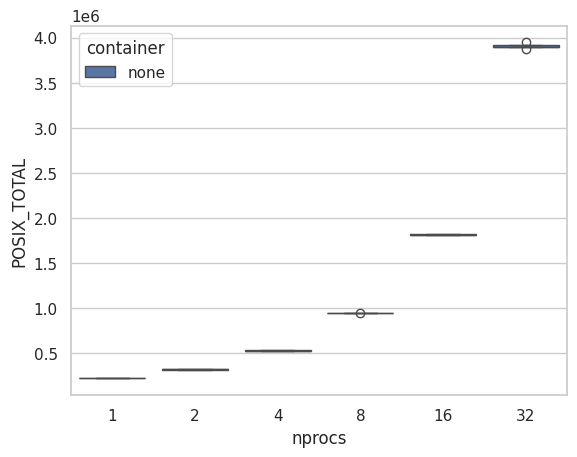

In [8]:
import seaborn as sb

module_operations = [
    "POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS", 
    "POSIX_MMAPS", "POSIX_FSYNCS", "POSIX_FDSYNCS", "STDIO_OPENS", "STDIO_READS",
    "STDIO_WRITES", "STDIO_SEEKS", "STDIO_FLUSHES"
]
df = darshan_data[METADATA_COLUMNS + module_operations]

df["nprocs"] = pd.to_numeric(df["nprocs"])
df["POSIX_TOTAL"] = df[["POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS", 
    "POSIX_MMAPS", "POSIX_FSYNCS", "POSIX_FDSYNCS"]].sum(axis=1, numeric_only=True)
df["STDIO_TOTAL"] = df[["STDIO_OPENS", "STDIO_READS",
    "STDIO_WRITES", "STDIO_SEEKS", "STDIO_FLUSHES"]].sum(axis=1, numeric_only=True)
df = df[METADATA_COLUMNS + ["POSIX_TOTAL", "STDIO_TOTAL"]]
df = df.sort_values(by=["nprocs"])
df = df.groupby(by=["nprocs", "run", "container"]).agg({"POSIX_TOTAL": "sum", "STDIO_TOTAL": "sum"}).reset_index()
df

sb.set_theme(style="whitegrid")
sb.boxplot(data=df, x="nprocs", y="POSIX_TOTAL", hue="container")

In [ ]:
import seaborn as sb

# TODO:: include stdio
# MMAPS removed due to bad value (-1), not included in data or metadata ops anyway

module_operations = [
    "POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS", 
    "POSIX_FSYNCS", "POSIX_FDSYNCS", "STDIO_OPENS", "STDIO_READS", 
    "STDIO_WRITES", "STDIO_SEEKS", "STDIO_FLUSHES"
]

df = darshan_data[METADATA_COLUMNS + module_operations]
df["nprocs"] = pd.to_numeric(df["nprocs"])
df["POSIX_METADATA_OPS"] = df[["POSIX_OPENS", "POSIX_SEEKS", "POSIX_STATS"]].sum(axis=1, numeric_only=True)
df["POSIX_DATA_OPS"] = df[["POSIX_READS", "POSIX_WRITES", "POSIX_FSYNCS", "POSIX_FDSYNCS"]].sum(axis=1, numeric_only=True)
df["STDIO_METADATA_OPS"] = df[["STDIO_OPENS", "STDIO_SEEKS"]].sum(axis=1, numeric_only=True)
df["STDIO_DATA_OPS"] = df[["STDIO_READS", "STDIO_WRITES"]].sum(axis=1, numeric_only=True)
df = df.groupby(by=["nprocs", "run", "container", "file_name"]).agg({
    "process": "unique",
    "POSIX_METADATA_OPS": "sum",
    "POSIX_DATA_OPS": "sum",
    "STDIO_METADATA_OPS": "sum",
    "STDIO_DATA_OPS": "sum"
}).reset_index()
df["IS_GLOBAL"] = df["process"].str.len() == df["nprocs"] + 3
df = df.groupby(by=["nprocs", "run", "container", "IS_GLOBAL"]).agg({
    "POSIX_METADATA_OPS": "sum",
    "POSIX_DATA_OPS": "sum",
    "STDIO_METADATA_OPS": "sum",
    "STDIO_DATA_OPS": "sum"
})
# print(df.columns[df.eq(-1.0).any()])
df

sb.boxenplot(df, x="nprocs", y="", hue="")

POSIX_METADATA_OPS  POSIX_DATA_OPS  \
nprocs run container IS_GLOBAL                                       
1      3   none      False                 61519.0        121379.0   
                     True                  27301.0         15342.0   
       4   none      False                 61519.0        121381.0   
                     True                  27301.0         15342.0   
       5   none      False                 61519.0        121331.0   
                     True                  27301.0         15342.0   
       6   none      False                 61519.0        121375.0   
                     True                  27301.0         15342.0   
       7   none      False                 61519.0        121342.0   
                     True                  27301.0         15342.0   
2      1   none      False                 68838.0        191193.0   
                     True                  46977.0         25676.0   
       2   none      False                 68833.0        182848.0   
                     True                  46977.0         25676.0   
       3   none      False                 68833.0        191321.0   
                     True                  46977.0         25676.0   
       4   none      False                 68833.0        191051.0   
                     True                  46977.0         25676.0   
       5   none      False                 68839.0        181580.0   
                     True                  46977.0         25676.0   
4      1   none      False                 83654.0        321726.0   
                     True                  85857.0         46108.0   
       2   none      False                 83658.0        322860.0   
                     True                  85857.0         46108.0   
       3   none      False                 83647.0        317433.0   
                     True                  85857.0         46108.0   
       4   none      False                 83643.0        317344.0   
                     True                  85857.0         46108.0   
       5   none      False                 83643.0        315445.0   
                     True                  85857.0         46108.0   
8      1   none      False                113066.0        587770.0   
                     True                 163751.0         87039.0   
       2   none      False                113048.0        587979.0   
                     True                 163751.0         87039.0   
       3   none      False                113069.0        587339.0   
                     True                 163751.0         87039.0   
       4   none      False                112978.0        587990.0   
                     True                 163751.0         87039.0   
       5   none      False                113002.0        586003.0   
                     True                 163751.0         87039.0   
16     1   none      False                172452.0       1162756.0   
                     True                 319983.0        169123.0   
       2   none      False                172435.0       1166178.0   
                     True                 319983.0        169123.0   
       3   none      False                172422.0       1162243.0   
                     True                 319983.0        169123.0   
       4   none      False                172439.0       1165951.0   
                     True                 319983.0        169123.0   
       5   none      False                172363.0       1163486.0   
                     True                 319983.0        169123.0   
32     1   none      False                291096.0       2656131.0   
                     True                 633117.0        333626.0   
       2   none      False                289948.0       2633723.0   
                     True                 633117.0        333626.0   
       3   none      False                293183.0       2701419.0   
                     True                 